# 4. Advanced Analysis: Clustering Political Manifestos

In this notebook, we extend the previous similarity analysis by investigating the internal structure of political manifestos.

While similarity analysis focuses on pairwise relationships between documents, clustering allows us to uncover global patterns in the dataset.

The main objective is to determine whether manifestos form coherent groups in semantic space, potentially reflecting differences in political discourse, rhetorical strategies, or thematic focus.

To achieve this, we:
- compute sentence embeddings
- apply clustering techniques
- visualize the structure using PCA
- analyze cluster coherence and interpretability

In [48]:
import os
import re
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
from google.colab import files
uploaded = files.upload()

Saving legislatives (1).zip to legislatives (1) (1).zip


In [50]:
zip_path = "/content/legislatives (1).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Extraction completed")

Extraction completed


In [51]:
os.listdir("/content")

['.config',
 'legislatives (1) (1).zip',
 'pca_clusters.png',
 'legislatives (1).zip',
 'text_files',
 'sample_data']

In [52]:
folder = "/content/text_files/1988/legislatives"

data = []

for filename in os.listdir(folder):
    if filename.endswith(".txt"):
        with open(os.path.join(folder, filename), "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        data.append({"id": filename, "text": text})

df = pd.DataFrame(data)

print("Number of documents:", len(df))
df.head()

Number of documents: 3628


,id,text
0,EL174_L_1988_06_003_01_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LÉGISLA...
1,EL175_L_1988_06_050_01_2_PF_01.txt,Michel ROCARD 1er Ministre\nvous demande d'app...
2,EL176_L_1988_06_056_06_1_PF_02.txt,Sciences Po / fonds CEVIPOF\nMajorité présiden...
3,EL175_L_1988_06_048_01_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANCA...
4,EL177_L_1988_06_088_03_2_PF_01.txt,Elections législatives du 12 Juin 1988 DÉPARTE...


In [53]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

In [54]:
df_sample = df.sample(n=500, random_state=42).reset_index(drop=True)

## 4.1 Semantic representation of documents

To capture the meaning of each manifesto, we use sentence embeddings generated by a pretrained transformer model.

Unlike TF-IDF, which relies on word frequency, embeddings encode semantic information in a dense vector space.

This allows documents to be compared based on meaning rather than exact word overlap, which is particularly important in political texts where similar ideas may be expressed using different vocabulary.

In [55]:
!pip install sentence-transformers

In [56]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df_sample["clean_text"].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embeddings shape: (500, 384)


## 4.2 Clustering methodology

Clustering is an unsupervised learning technique used to group similar documents together.

We apply the K-Means algorithm, which partitions the data into a predefined number of clusters by minimizing the distance between documents and cluster centroids.

In this context, clustering allows us to explore whether political manifestos naturally group into distinct categories, possibly reflecting different ideological positions or rhetorical styles.

In [57]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(embeddings)

df_sample["cluster"] = labels

In [58]:
df_sample["cluster"].value_counts()

,count
cluster,
0,142
1,134
3,126
4,55
2,43


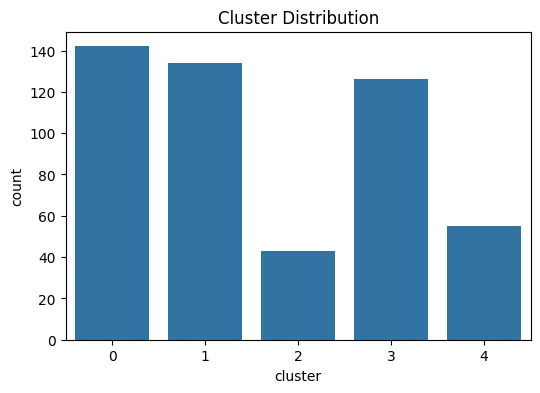

In [59]:
plt.figure(figsize=(6,4))
sns.countplot(x=df_sample["cluster"])
plt.title("Cluster Distribution")
plt.show()

### Cluster distribution

The distribution of documents across clusters provides an initial indication of how the data is structured.

A balanced distribution suggests that multiple types of discourse are present, while highly uneven clusters may indicate dominant patterns or outliers.

## 4.3 Dimensionality reduction with PCA

To visualize the high-dimensional embedding space, we apply Principal Component Analysis (PCA).

PCA projects the data into a lower-dimensional space while preserving as much variance as possible.

Although this projection inevitably loses information, it provides a useful way to visually inspect the structure of the dataset and identify potential groupings.

In [60]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(embeddings)

df_sample["pca_1"] = reduced[:,0]
df_sample["pca_2"] = reduced[:,1]

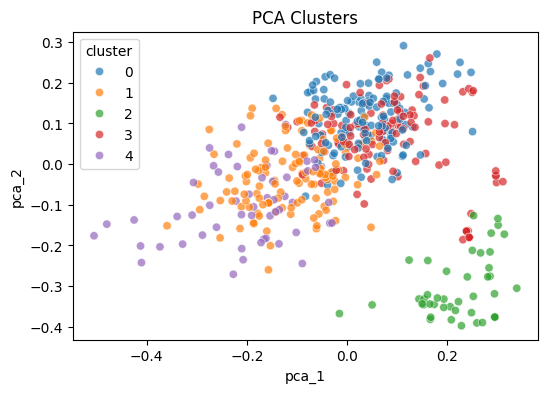

In [61]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="pca_1",
    y="pca_2",
    hue="cluster",
    data=df_sample,
    palette="tab10",
    alpha=0.7
)
plt.title("PCA Clusters")
plt.show()

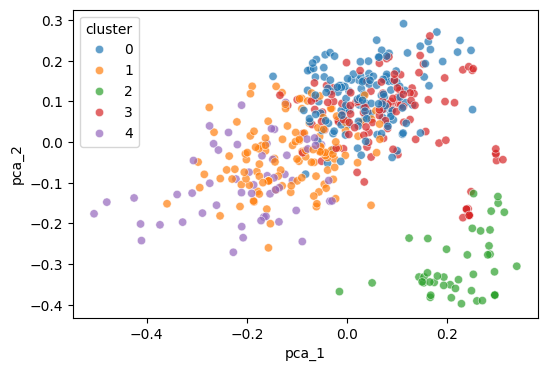

In [62]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="pca_1",
    y="pca_2",
    hue="cluster",
    data=df_sample,
    palette="tab10",
    alpha=0.7
)
plt.savefig("pca_clusters.png", dpi=200, bbox_inches="tight")
plt.show()

### Visual interpretation

The PCA plot reveals how documents are distributed in semantic space.

If clusters appear clearly separated, this suggests that the embedding model captures meaningful distinctions between manifestos.

Conversely, overlapping clusters may indicate that political discourse shares common structures across different documents.

## 4.4 Cluster interpretation

To better understand the nature of each cluster, we inspect sample documents.

This qualitative analysis is essential, as clustering alone does not provide semantic labels.

By examining representative texts, we can identify recurring themes, rhetorical patterns, or stylistic differences within each cluster.

In [63]:
def preview(text, n=500):
    return text[:n] + "..."

for c in range(5):
    print(f"\n\n--- CLUSTER {c} ---")

    subset = df_sample[df_sample["cluster"] == c]["text"].head(2)

    for t in subset:
        print(preview(t))
        print("\n")



--- CLUSTER 0 ---
Sciences Po / fonds CEVIPOF
POUR RASSEMBLER LES FORCES DE GAUCHE
DANIEL BARTKOWIAK CONSEILLER REGIONAL DE LORRAINE
JUSTICE LIBERTÉ PAIX
JEAN-CLAUDE SCHMIDT MAIRE ADJOINT DE BEHREN-LES-FORBACH
CANDIDATS PRÉSENTÉS PAR LE PARTI COMMUNISTE FRANÇAIS
Vu le candidat
ÉLECTIONS LÉGISLATIVES - 6e CIRCONSCRIPTION - 5-12 JUIN 1988Madame, Mademoiselle, Monsieur,
Je suis, comme une majorité d'entre vous, pro- fondément attaché aux valeurs de gauche, celles de justice sociale, de liberté et de paix. Elles cons...


ÉLECTIONS LÉGISLATIVES DE JUIN 1988 Département de l'Aisne - 3e Circonscription - 5-12 juin 1988
Jacques BOURY
En Thiérache depuis 5 générations, né à Thenailles il y a 55 ans, marié, agriculteur, je suis candidat aux élections législatives.
Mon suppléant est Jean FONTAINE, Maire de Parpeville depuis 20 ans.
Électrices, Électeurs,
Les Françaises et les Français constatent que, depuis sa réélection à la présidence de la République, M. MITTERRAND cher- che à assurer le ma

## 4.5 Intra-cluster similarity

We compute average similarity within each cluster to evaluate cluster coherence.

In [64]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(embeddings)

cluster_scores = []

for c in range(5):
    indices = df_sample[df_sample["cluster"] == c].index

    if len(indices) > 1:
        submatrix = sim_matrix[np.ix_(indices, indices)]
        avg_sim = submatrix.mean()
        cluster_scores.append((c, avg_sim))

cluster_scores

[(0, np.float32(0.7377859)),
 (1, np.float32(0.6685954)),
 (2, np.float32(0.8945514)),
 (3, np.float32(0.76238894)),
 (4, np.float32(0.6297622))]

## 4.6 Conclusion

The results of this analysis suggest that political manifestos exhibit a structured organization in semantic space.

Clustering reveals that documents can be grouped into coherent categories, which may correspond to differences in political messaging, thematic focus, or rhetorical style.

The PCA visualization supports this interpretation by highlighting non-random distributions of documents.

Overall, these findings demonstrate that embedding-based representations are effective tools for uncovering latent structures in political discourse.